In [1]:
# Useful starting lines
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

# Load the data

In [2]:
import datetime
from helpers import *

height, weight, gender = load_data(sub_sample=False, add_outlier=False)
x, mean_x, std_x = standardize(height)
y, tx = build_model_data(x, weight)

In [3]:
y.shape, tx.shape

((10000,), (10000, 2))

### NB: throughout this laboratory the data has the following format: 
  * there are **N = 10000** data entries
  * **y** represents the column vector containing weight information -- that which we wish to predict/the output (see also the first page of $\texttt{exercise02.pdf}$). Its **shape** is **(N,)**.
  * **tx** represents the matrix $\tilde{X}$ formed by laterally concatenating a column vector of 1s to the column vector of height information -- the input data (see also the first page of $\texttt{exercise02.pdf}$). Its **shape** is **(N,2)**.

# 1. Computing the Cost Function
Fill in the `compute_loss` function below:

In [5]:
def compute_loss(y, tx, w):
    """Calculate the loss using either MSE or MAE.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2,). The vector of model parameters.

    Returns:
        the value of the loss (a scalar), corresponding to the input parameters w.
    """
    e = y - tx.dot(w)
    return e.dot(e) / (2 * len(y))

w = np.array([1, 2])
print(compute_loss(y, tx, w))

2694.4833658870834


# 2. Grid Search

Fill in the function `grid_search()` below:

In [7]:
# from costs import *


def grid_search(y, tx, grid_w0, grid_w1):
    """Algorithm for grid search.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        grid_w0: numpy array of shape=(num_grid_pts_w0, ). A 1D array containing num_grid_pts_w0 values of parameter w0 to be tested in the grid search.
        grid_w1: numpy array of shape=(num_grid_pts_w1, ). A 1D array containing num_grid_pts_w1 values of parameter w1 to be tested in the grid search.

    Returns:
        losses: numpy array of shape=(num_grid_pts_w0, num_grid_pts_w1). A 2D array containing the loss value for each combination of w0 and w1
    """

    losses = np.zeros((len(grid_w0), len(grid_w1)))
   # C'est exactement comme chercher le plus petit nombre dans une liste 
   # à la main : tu gardes en mémoire "le plus petit vu jusqu'ici", 
   # et tu compares chaque nouveau candidat à cette mémoire.
   
    for i, w0_i in enumerate(grid_w0):
        for j, w1_j in enumerate(grid_w1):
            w = np.array([w0_i, w1_j])
            losses[i, j] = compute_loss(y, tx, w)
        
    return losses

Let us play with the grid search demo now!

Grid Search: loss*=42.42448314678197, w0*=66.66666666666669, w1*=16.666666666666686, execution time=0.004 seconds


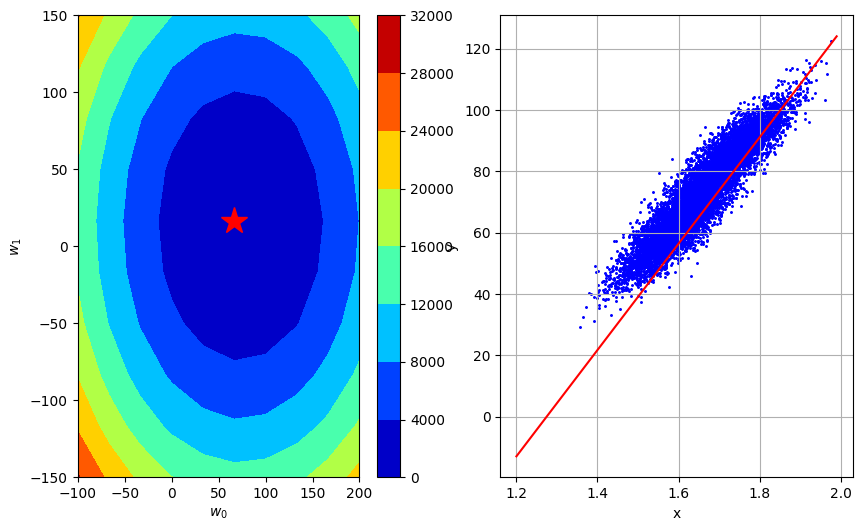

In [11]:
from grid_search import generate_w, get_best_parameters
from plots import grid_visualization

# Generate the grid of parameters to be swept
grid_w0, grid_w1 = generate_w(num_intervals=10)

# Start the grid search
start_time = datetime.datetime.now()
grid_losses = grid_search(y, tx, grid_w0, grid_w1)

# Select the best combinaison
loss_star, w0_star, w1_star = get_best_parameters(grid_w0, grid_w1, grid_losses)
end_time = datetime.datetime.now()
execution_time = (end_time - start_time).total_seconds()

# Print the results
print(
    "Grid Search: loss*={l}, w0*={w0}, w1*={w1}, execution time={t:.3f} seconds".format(
        l=loss_star, w0=w0_star, w1=w1_star, t=execution_time
    )
)

# Plot the results
fig = grid_visualization(grid_losses, grid_w0, grid_w1, mean_x, std_x, height, weight)
fig.set_size_inches(10.0, 6.0)
fig.savefig("grid_plot")  # Optional saving

In [9]:
losses = grid_search(y, tx, grid_w0, grid_w1)   # appel de ta fonction

# extraction du minimum — PAS dans grid_search, ici dans le notebook
i_min, j_min = np.unravel_index(np.argmin(losses), losses.shape)
w0_star, w1_star = grid_w0[i_min], grid_w1[j_min]

# 3. Gradient Descent

Again, please fill in the functions `compute_gradient` below:

In [12]:
def compute_gradient(y, tx, w):
    """Computes the gradient at w.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        An numpy array of shape (2, ) (same shape as w), containing the gradient of the loss at w.
    """
    e = y - tx.dot(w)
    grad = -tx.T.dot(e) / len(y)
    return grad

Please fill in the functions `gradient_descent` below:

In [13]:
def gradient_descent(y, tx, initial_w, max_iters, gamma):
    """The Gradient Descent (GD) algorithm.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        max_iters: a scalar denoting the total number of iterations of GD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of GD
        ws: a list of length max_iters + 1 containing the model parameters as numpy arrays of shape (2, ),
            for each iteration of GD (as well as the final weights)
    """
    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    
    w = initial_w
    
    for n_iter in range(max_iters):
        loss = compute_loss(y, tx, w)
        losses.append(loss)
        w = w - gamma*compute_gradient(y,tx,w) 
        ws.append(w)
        # store w and loss
      
        
        print(
            "GD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )

    return losses, ws

Test your gradient descent function through gradient descent demo shown below:

In [26]:
# from gradient_descent import *
from plots import gradient_descent_visualization

# Define the parameters of the algorithm.
max_iters = 1000
gamma = 0.01

# Initialization
w_initial = np.array([0, 0])

# Start gradient descent.
start_time = datetime.datetime.now()
gd_losses, gd_ws = gradient_descent(y, tx, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("GD: execution time={t:.3f} seconds".format(t=exection_time))

GD iter. 0/999: loss=2792.2367127591674, w0=0.7329392200210505, w1=0.134797124349894
GD iter. 1/999: loss=2736.977381343849, w0=1.4585490478418917, w1=0.2682462774562885
GD iter. 2/999: loss=2682.8177106236963, w0=2.1769027773845258, w1=0.4003609390316184
GD iter. 3/999: loss=2629.7358173508746, w0=2.8880729696317315, w1=0.5311544539911958
GD iter. 4/999: loss=2577.710253754182, w0=3.592131459956467, w1=0.6606400338011762
GD iter. 5/999: loss=2526.719998873063, w0=4.289149365377953, w1=0.7888307578130571
GD iter. 6/999: loss=2476.7444500640786, w0=4.979197091745226, w1=0.9157395745848198
GD iter. 7/999: loss=2427.763414676393, w0=5.662344340848825, w1=1.0413793031888643
GD iter. 8/999: loss=2379.757101892923, w0=6.338660117461387, w1=1.1657626345068688
GD iter. 9/999: loss=2332.7061147338436, w0=7.008212736307826, w1=1.2889021325116934
GD iter. 10/999: loss=2286.591442219229, w0=7.671069828965799, w1=1.4108102355364691
GD iter. 11/999: loss=2241.3944516876563, w0=8.327298350697193, w1=

interactive(children=(IntSlider(value=1, description='n_iter', max=1001, min=1), Output()), _dom_classes=('wid…

<function __main__.plot_figure(n_iter)>

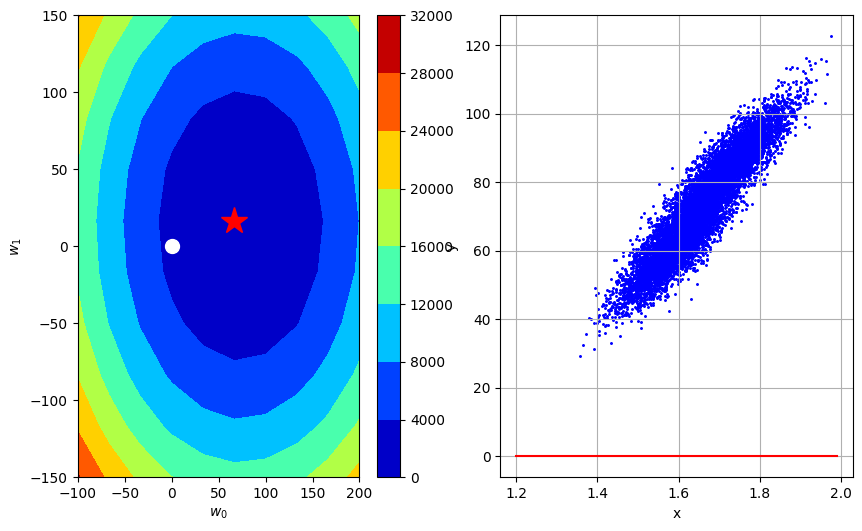

In [20]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        gd_losses,
        gd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(gd_ws)))

# 4. Stochastic gradient descent

In [22]:
def compute_stoch_gradient(y, tx, w):
    """Compute a stochastic gradient at w from a data sample batch of size B, where B < N, and their corresponding labels.

    Args:
        y: numpy array of shape=(B, )
        tx: numpy array of shape=(B,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        A numpy array of shape (2, ) (same shape as w), containing the stochastic gradient of the loss at w.
    """

    return compute_gradient(y,tx,w)


def stochastic_gradient_descent(y, tx, initial_w, batch_size, max_iters, gamma):
    """The Stochastic Gradient Descent algorithm (SGD).

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        batch_size: a scalar denoting the number of data points in a mini-batch used for computing the stochastic gradient
        max_iters: a scalar denoting the total number of iterations of SGD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SGD
    """

    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w

    for n_iter in range(max_iters):
        for minibatch_y, minibatch_tx in batch_iter(y, tx, batch_size=batch_size, num_batches=1):
            grad = compute_stoch_gradient(minibatch_y, minibatch_tx, w)
            w = w - gamma * grad
            loss = compute_loss(y, tx, w)
            losses.append(loss)
            ws.append(w)

        print(
            "SGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )
    return losses, ws

In [24]:
# from stochastic_gradient_descent import *

# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.1
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SGD.
start_time = datetime.datetime.now()
sgd_losses, sgd_ws = stochastic_gradient_descent(
    y, tx, w_initial, batch_size, max_iters, gamma
)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SGD: execution time={t:.3f} seconds".format(t=exection_time))

SGD iter. 0/49: loss=2449.88771959862, w0=6.27565262408342, w1=-5.951068121501486
SGD iter. 1/49: loss=1756.4991641350784, w0=15.113645901231582, w1=3.616547356850271
SGD iter. 2/49: loss=1434.914288613035, w0=20.670969840293896, w1=5.12018450189766
SGD iter. 3/49: loss=1213.9062662362746, w0=26.091815176890947, w1=0.47964058918930874
SGD iter. 4/49: loss=948.1975305362217, w0=32.060994118075946, w1=0.6162392086310196
SGD iter. 5/49: loss=855.5751206251264, w0=35.05479123205064, w1=-1.290099461689331
SGD iter. 6/49: loss=845.4934875418365, w0=35.82476501264832, w1=-2.5289562743524674
SGD iter. 7/49: loss=715.9666044233849, w0=40.4271341105224, w1=-4.4349655358486615
SGD iter. 8/49: loss=550.8528466349103, w0=44.935928833131534, w1=-2.85301976022573
SGD iter. 9/49: loss=300.70026533648246, w0=50.99402729455836, w1=4.9156333270153105
SGD iter. 10/49: loss=292.8095689210426, w0=51.97798023276409, w1=3.455841496549799
SGD iter. 11/49: loss=282.81366554053517, w0=53.292439735202294, w1=1.86

interactive(children=(IntSlider(value=1, description='n_iter', max=51, min=1), Output()), _dom_classes=('widge…

<function __main__.plot_figure(n_iter)>

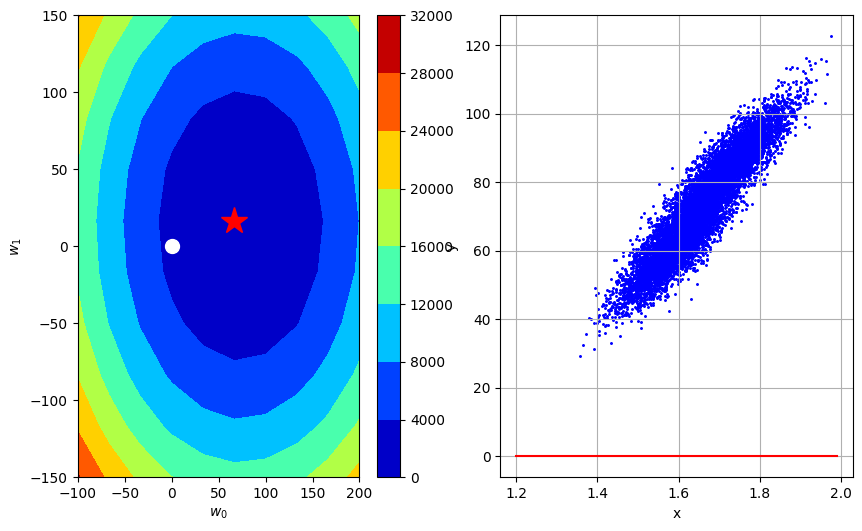

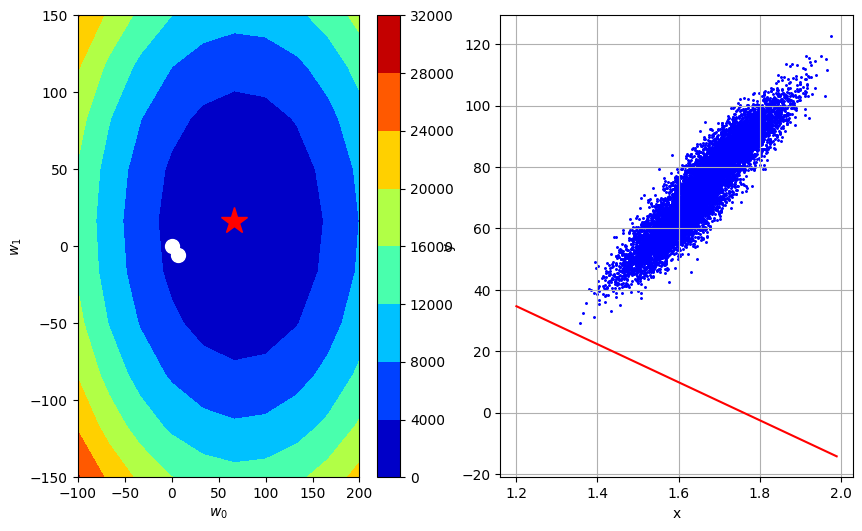

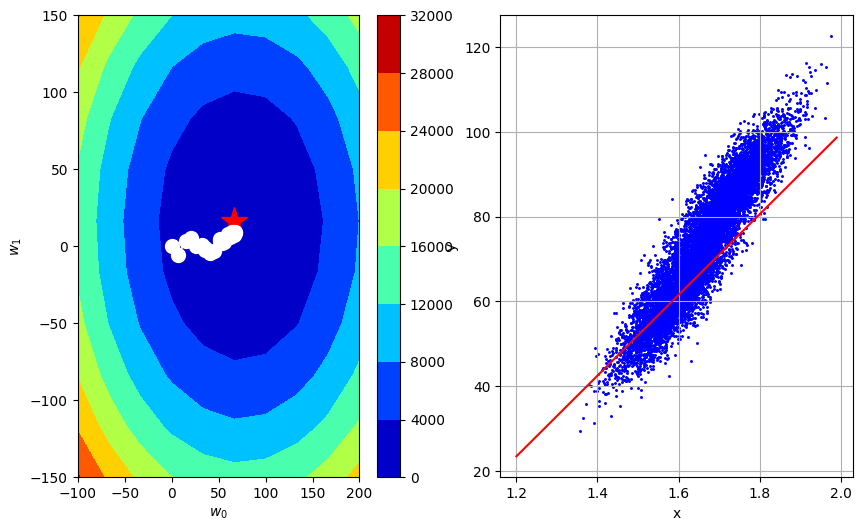

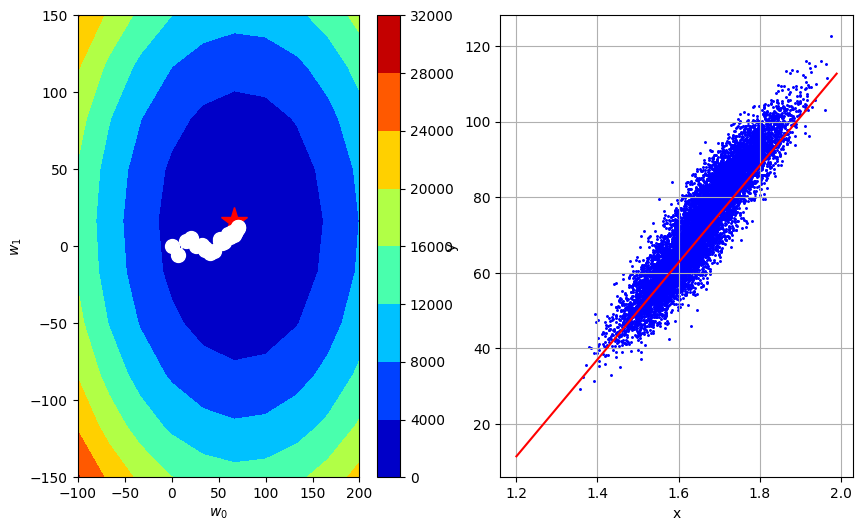

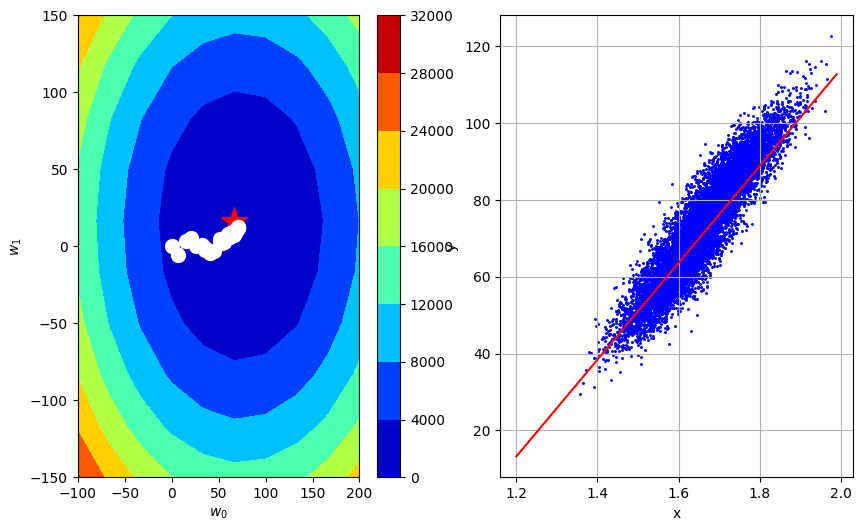

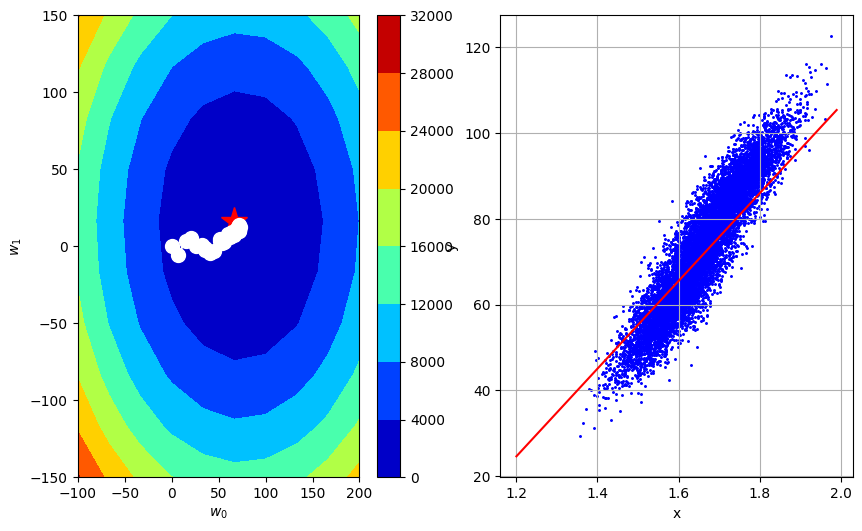

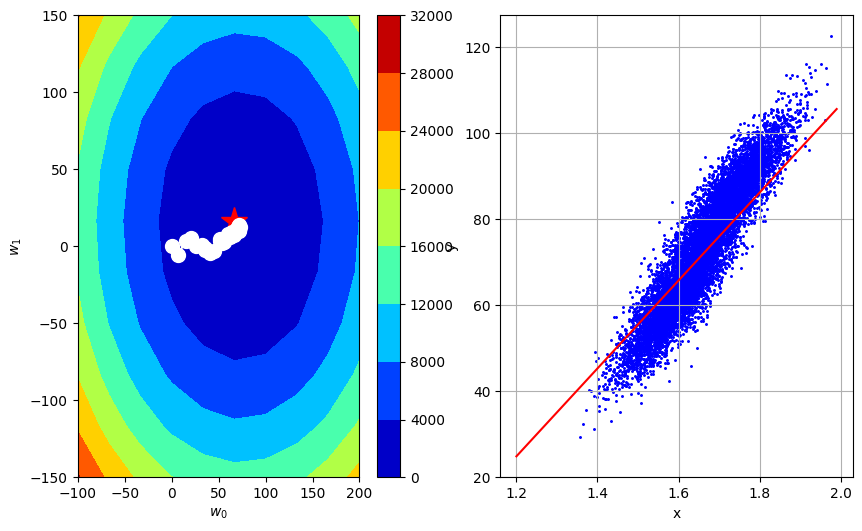

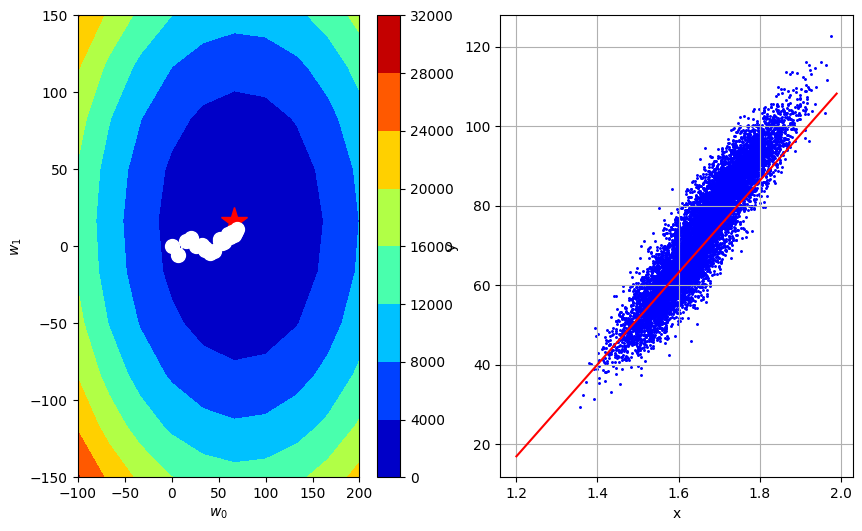

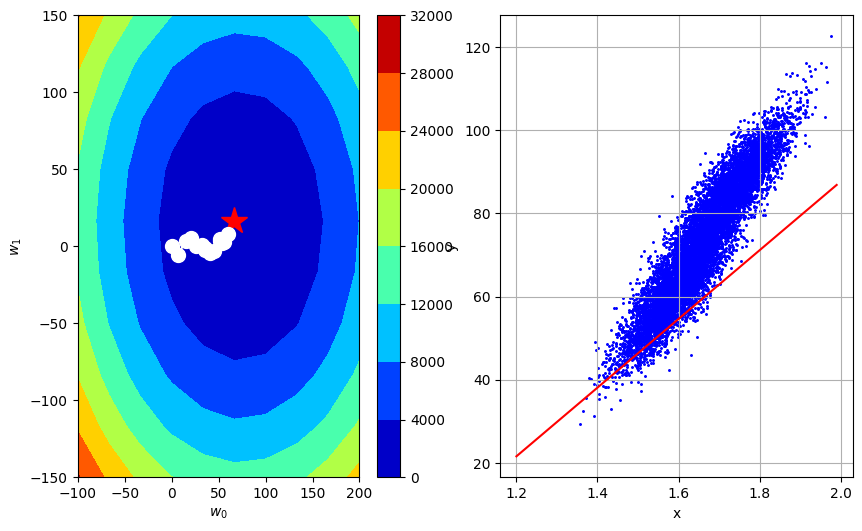

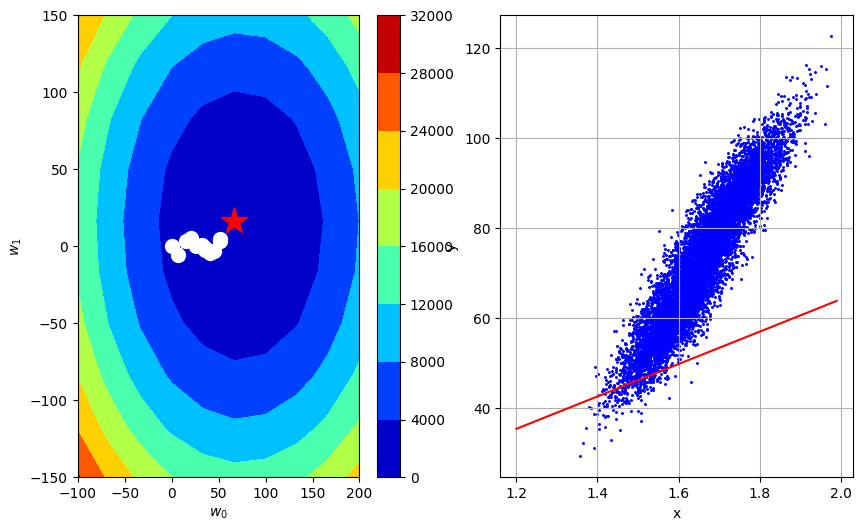

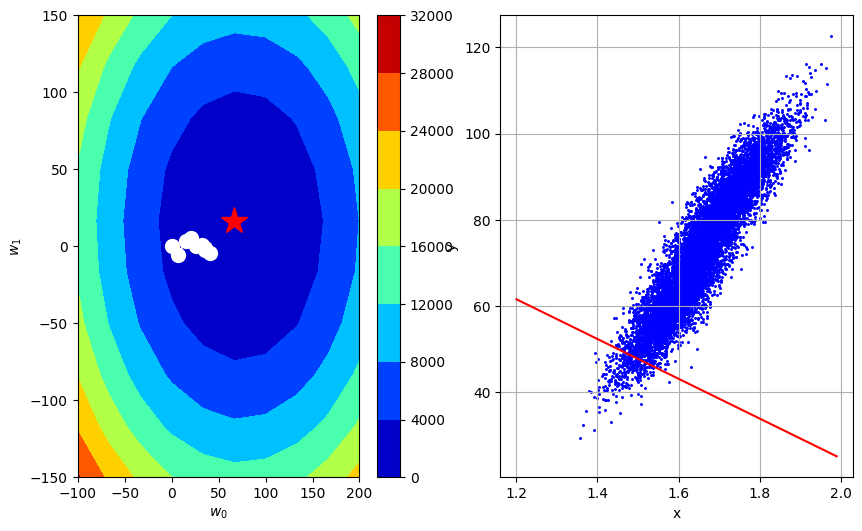

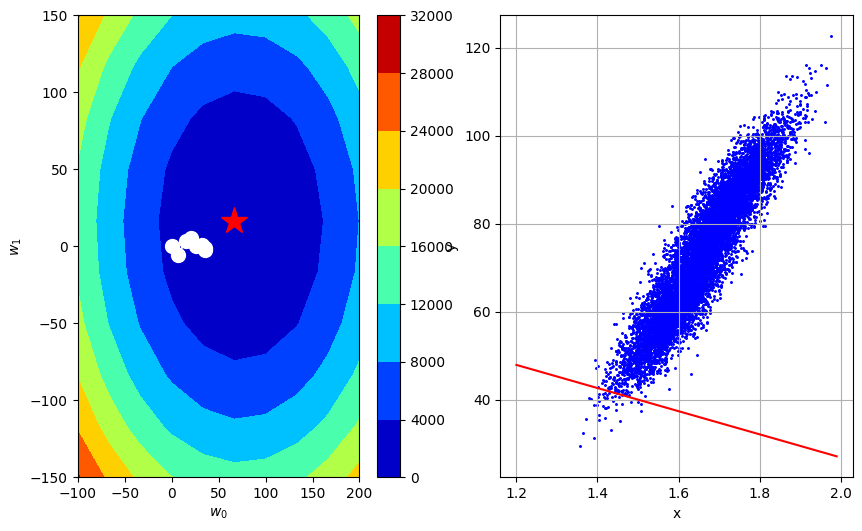

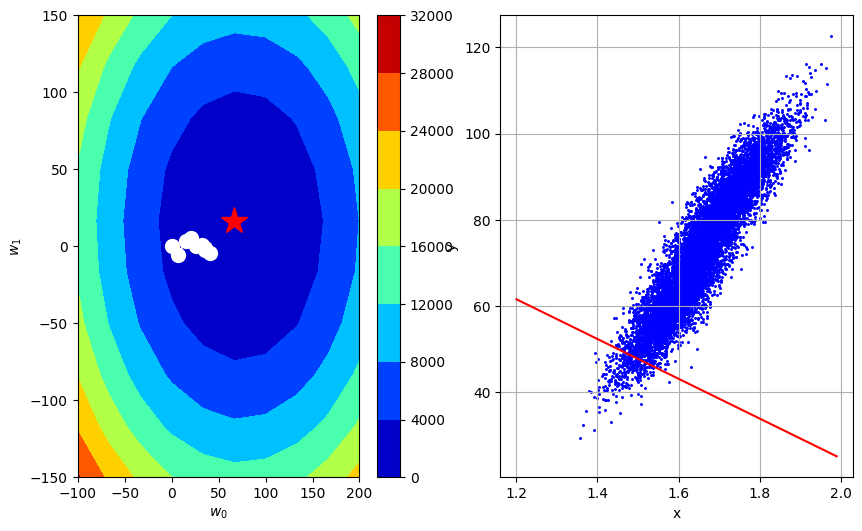

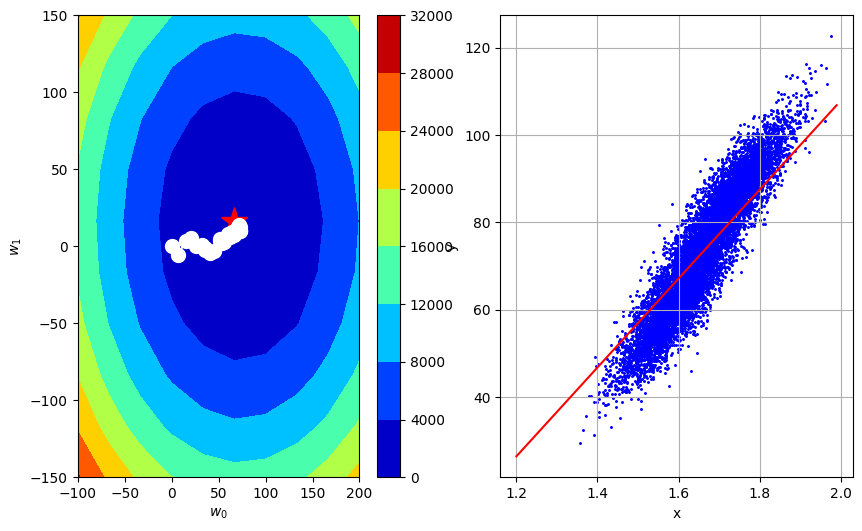

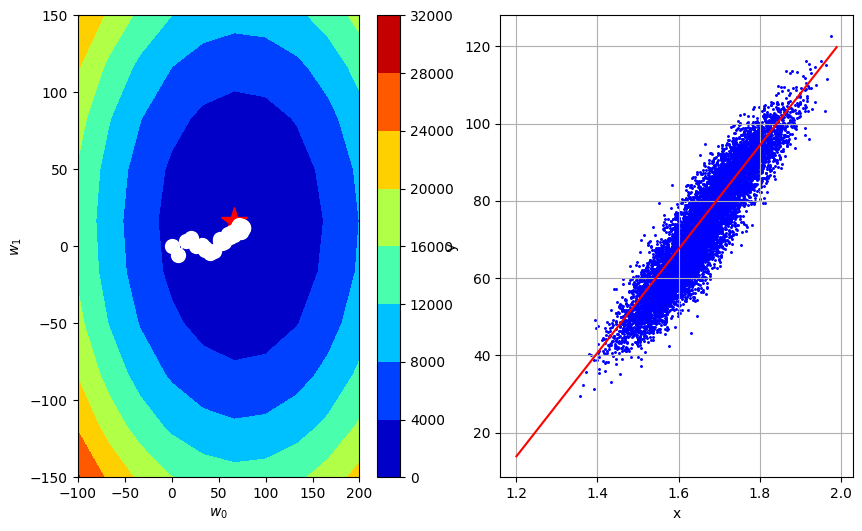

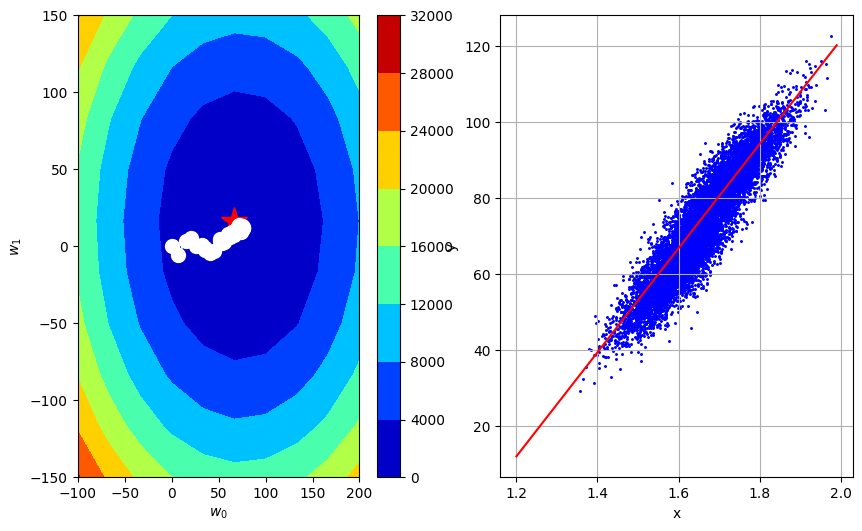

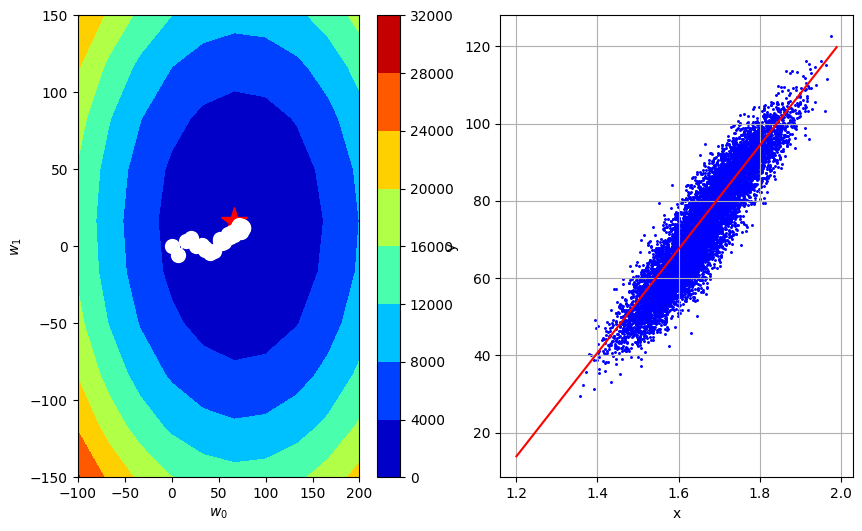

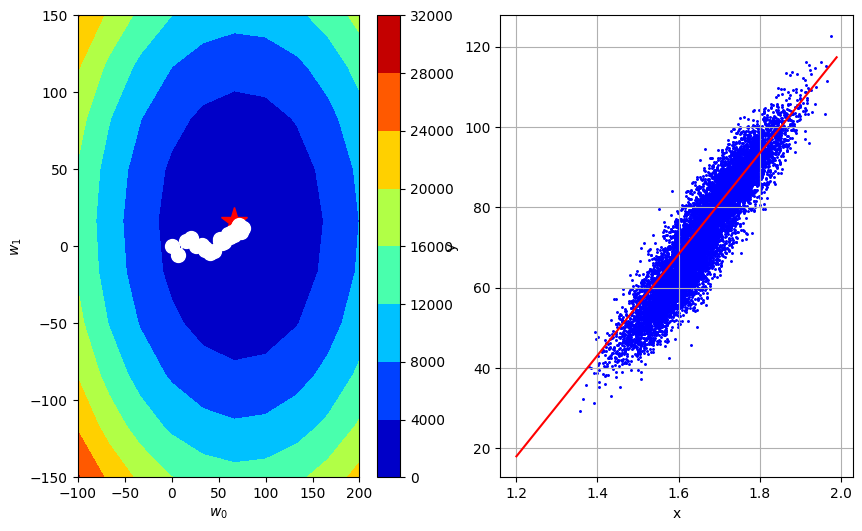

In [25]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        sgd_losses,
        sgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(sgd_ws)))

# 5. Effect of Outliers and MAE Cost Function

In [27]:
import datetime
from helpers import *

height, weight, gender = load_data(sub_sample=True, add_outlier=False)
height_outlier, weight_outlier, gender_outlier = load_data(sub_sample=True, add_outlier=True)

x, mean_x, std_x = standardize(height)
y, tx = build_model_data(x, weight)

In [28]:
y.shape, tx.shape

((200,), (200, 2))

In [30]:
from plots import gradient_descent_visualization

# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.7

# Initialization
w_initial = np.array([0, 0])

# Start gradient descent.
start_time = datetime.datetime.now()

gradient_losses, gradient_ws = gradient_descent(y, tx, w_initial, max_iters, gamma)
w_star = gradient_ws[-1]



end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("GD: execution time={t:.3f} seconds".format(t=exection_time))

GD iter. 0/49: loss=2829.2722244384163, w0=51.54259072181176, w1=10.132993413506084
GD iter. 1/49: loss=267.0500258779429, w0=67.0053679383553, w1=13.172891437557825
GD iter. 2/49: loss=36.45002800750045, w0=71.64420110331838, w1=14.084860844773322
GD iter. 3/49: loss=15.696028199160635, w0=73.03585105280729, w1=14.358451666937965
GD iter. 4/49: loss=13.828168216410077, w0=73.45334603765397, w1=14.440528913587356
GD iter. 5/49: loss=13.660060817962522, w0=73.57859453310797, w1=14.46515208758217
GD iter. 6/49: loss=13.644931152102245, w0=73.61616908174418, w1=14.472539039780616
GD iter. 7/49: loss=13.643569482174817, w0=73.62744144633503, w1=14.474755125440149
GD iter. 8/49: loss=13.643446931881352, w0=73.63082315571229, w1=14.47541995113801
GD iter. 9/49: loss=13.643435902354941, w0=73.63183766852546, w1=14.475619398847368
GD iter. 10/49: loss=13.643434909697557, w0=73.63214202236942, w1=14.475679233160175
GD iter. 11/49: loss=13.643434820358397, w0=73.6322333285226, w1=14.475697183454

interactive(children=(IntSlider(value=1, description='n_iter', max=1001, min=1), Output()), _dom_classes=('wid…

<function __main__.plot_figure(n_iter)>

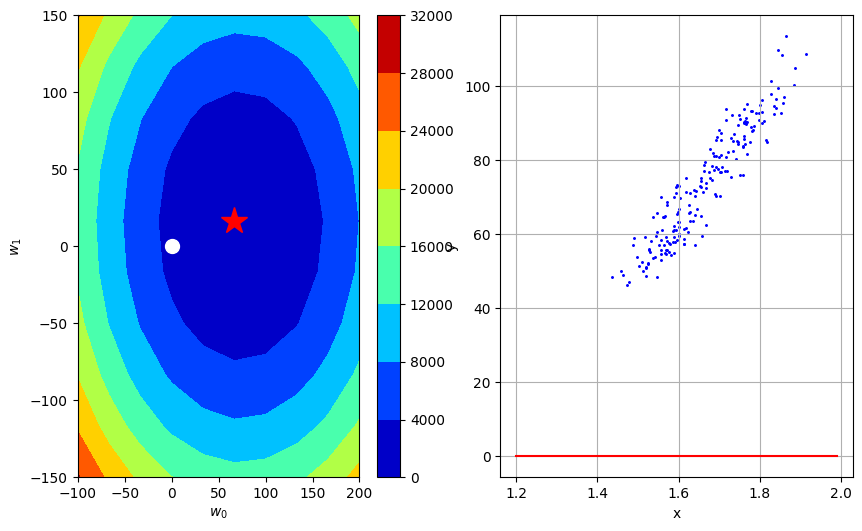

In [31]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        gd_losses,
        gd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(gd_ws)))

# 6. Subgradient descent

In [32]:
def compute_subgradient_mae(y, tx, w):
    """Compute a subgradient of the MAE at w.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        A numpy array of shape (2, ) (same shape as w), containing the subgradient of the MAE at w.
    """
    e = y - tx.dot(w)
    s = np.sign(e)
    return -tx.T.dot(s) / len(y)

In [36]:
def subgradient_descent(y, tx, initial_w, max_iters, gamma):
    """The SubGradient Descent (SubGD) algorithm.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        max_iters: a scalar denoting the total number of iterations of GD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SubGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SubGD
    """
    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w
    for n_iter in range(max_iters):
        loss = compute_loss(y, tx, w)
        losses.append(loss)
        
        w = compute_subgradient_mae(y,tx,w)
        ws.append(w)
       
        print(
            "SubGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )

    return losses, ws

In [37]:
# Define the parameters of the algorithm.
max_iters = 500
gamma = 0.7
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SubSGD.
start_time = datetime.datetime.now()
subgd_losses, subgd_ws = subgradient_descent(y, tx, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SubGD: execution time={t:.3f} seconds".format(t=exection_time))

SubGD iter. 0/499: loss=2829.2722244384163, w0=-1.0, w1=-2.41362485553509e-15
SubGD iter. 1/499: loss=2903.404496898147, w0=-1.0, w1=-2.41362485553509e-15
SubGD iter. 2/499: loss=2903.404496898147, w0=-1.0, w1=-2.41362485553509e-15
SubGD iter. 3/499: loss=2903.404496898147, w0=-1.0, w1=-2.41362485553509e-15
SubGD iter. 4/499: loss=2903.404496898147, w0=-1.0, w1=-2.41362485553509e-15
SubGD iter. 5/499: loss=2903.404496898147, w0=-1.0, w1=-2.41362485553509e-15
SubGD iter. 6/499: loss=2903.404496898147, w0=-1.0, w1=-2.41362485553509e-15
SubGD iter. 7/499: loss=2903.404496898147, w0=-1.0, w1=-2.41362485553509e-15
SubGD iter. 8/499: loss=2903.404496898147, w0=-1.0, w1=-2.41362485553509e-15
SubGD iter. 9/499: loss=2903.404496898147, w0=-1.0, w1=-2.41362485553509e-15
SubGD iter. 10/499: loss=2903.404496898147, w0=-1.0, w1=-2.41362485553509e-15
SubGD iter. 11/499: loss=2903.404496898147, w0=-1.0, w1=-2.41362485553509e-15
SubGD iter. 12/499: loss=2903.404496898147, w0=-1.0, w1=-2.41362485553509

In [ ]:
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        subgd_losses,
        subgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(subgd_ws)))

# Stochastic Subgradient Descent

**NB** for the computation of the subgradient you can reuse the `compute_subgradient` method that you implemented above, just making sure that you pass in a minibatch as opposed to the full data.

In [38]:
def stochastic_subgradient_descent(y, tx, initial_w, batch_size, max_iters, gamma):
    """Compute a stochastic subgradient at w from a data sample batch of size B, where B < N, and their corresponding labels.

    Args:
        y: numpy array of shape=(B, )
        tx: numpy array of shape=(B,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        batch_size: a scalar denoting the number of data points in a mini-batch used for computing the stochastic subgradient
        max_iters: a scalar denoting the total number of iterations of SubSGD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SubSGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SubSGD
    """

    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w

    for n_iter in range(max_iters):
        loss = compute_loss(y, tx, w)
        losses.append(loss)

        g = compute_subgradient_mae(y, tx, w)
        w = w - gamma * g

        ws.append(w)

        print(
            "SubSGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )
    return losses, ws

In [39]:
# Define the parameters of the algorithm.
max_iters = 500
gamma = 0.7
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SubSGD.
start_time = datetime.datetime.now()
subsgd_losses, subsgd_ws = stochastic_subgradient_descent(
    y, tx, w_initial, batch_size, max_iters, gamma
)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SubSGD: execution time={t:.3f} seconds".format(t=exection_time))

SubSGD iter. 0/499: loss=2829.2722244384163, w0=0.7, w1=1.689537398874563e-15
SubSGD iter. 1/499: loss=2777.974633716604, w0=1.4, w1=3.379074797749126e-15
SubSGD iter. 2/499: loss=2727.1670429947926, w0=2.0999999999999996, w1=5.068612196623689e-15
SubSGD iter. 3/499: loss=2676.8494522729807, w0=2.8, w1=6.758149595498252e-15
SubSGD iter. 4/499: loss=2627.021861551169, w0=3.5, w1=8.447686994372815e-15
SubSGD iter. 5/499: loss=2577.684270829357, w0=4.2, w1=1.0137224393247379e-14
SubSGD iter. 6/499: loss=2528.836680107545, w0=4.9, w1=1.1826761792121942e-14
SubSGD iter. 7/499: loss=2480.4790893857325, w0=5.6000000000000005, w1=1.3516299190996506e-14
SubSGD iter. 8/499: loss=2432.6114986639213, w0=6.300000000000001, w1=1.5205836589871068e-14
SubSGD iter. 9/499: loss=2385.2339079421095, w0=7.000000000000001, w1=1.689537398874563e-14
SubSGD iter. 10/499: loss=2338.3463172202974, w0=7.700000000000001, w1=1.8584911387620192e-14
SubSGD iter. 11/499: loss=2291.948726498486, w0=8.4, w1=2.0274448786

interactive(children=(IntSlider(value=1, description='n_iter', max=501, min=1), Output()), _dom_classes=('widg…

<function __main__.plot_figure(n_iter)>

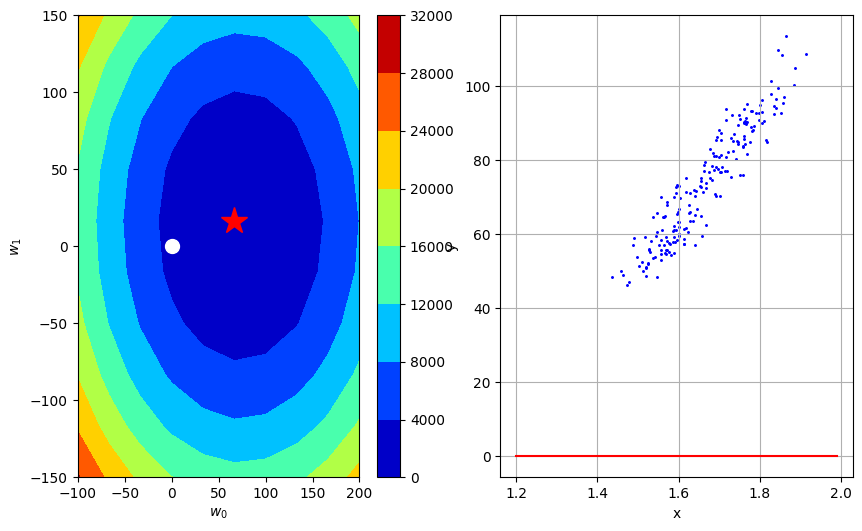

In [40]:
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        subsgd_losses,
        subsgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(subsgd_ws)))